<a href="https://colab.research.google.com/github/aditiupadhya/MyPythonProjectsPart1/blob/main/Geospatial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import numpy as np

In [7]:
data = [[1,2],[3,4]]
x_data = torch.tensor(data)

In [8]:
x_data

tensor([[1, 2],
        [3, 4]])

In [9]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [10]:
x_np

tensor([[1, 2],
        [3, 4]])

In [11]:
! pip install torchgeo

In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchgeo.datasets import EuroSAT100
import torch.nn.functional as F

In [13]:
training_data = EuroSAT100(
    root="data",
    split="train",
    download=True,
)

In [14]:
test_data = EuroSAT100(
    root="data",
    split ='val' ,
    download=True,
)

In [16]:
labels_map = {
    0:  "Annual Crop",
    1:  "Forest",
    2:  "Herbaceous Vegetation",
    3:  "Highway",
    4:  "Industrial Buildings",
    5:  "Pasture",
    6:  "Permanent Crop",
    7:  "Residential Buildings",
    8:  "River",
    9:  "Sea & Lake",
}

In [17]:
len(training_data)

60

In [18]:
import matplotlib.pyplot as plt

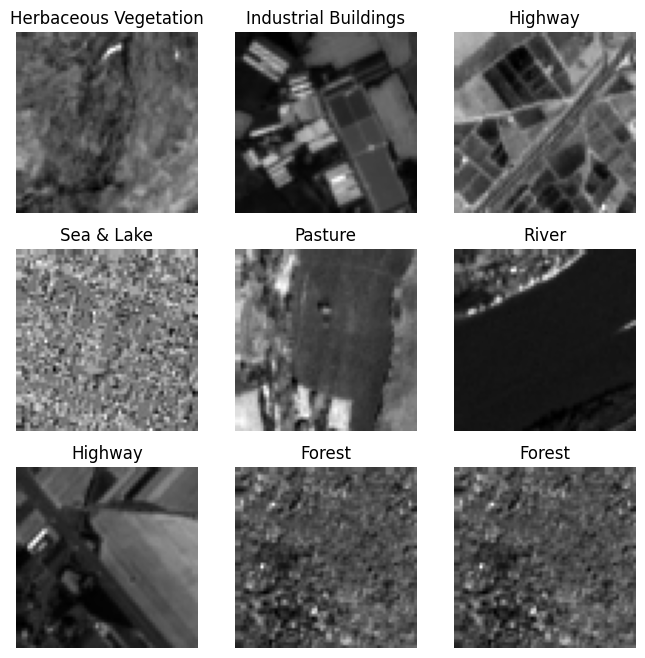

In [19]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  data = training_data[sample_idx]
  img, label = data['image'], data['label'].item()
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img[3], cmap="gray")
plt.show()

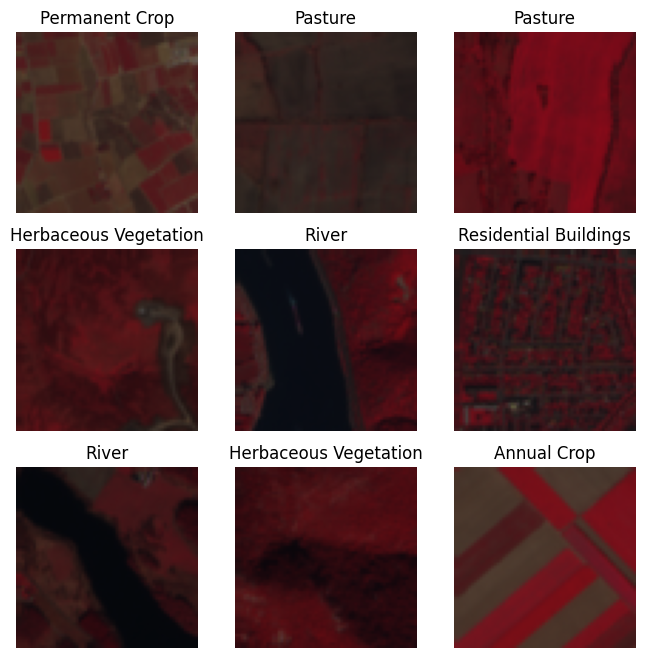

In [20]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  data = training_data[sample_idx]
  img, label = data['image'], data['label'].item()
  img = torch.stack((img[7], img[3], img[2]), dim=0)
  img = torch.permute(img, (1,2,0))

  figure.add_subplot(rows, cols,i)
  plt.title(labels_map[label])
  plt.axis("off")

  plt.imshow(img/10000.)
plt.show()

In [34]:
batch_size = 4

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

for data in test_dataloader:
  X = data['image']
  y = data['label']
  print(f"shape of X[N, C,H,W]: {X.shape}")
  print(f"shape of y: {y.shape} {y.dtype}")
  break

shape of X[N, C,H,W]: torch.Size([4, 13, 64, 64])
shape of y: torch.Size([4]) torch.int64


In [22]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"using{device} device")

usingcpu device


In [23]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(13*64*64*64, 512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, 32),
        nn.ReLU(),
        nn.Linear(32, 10)
    )

    def forward(self, x):
      x = self.flatten(x)
      logits = self.linear_relu_stack(x)
      return logits

In [24]:
model = NeuralNetwork().to(device)

In [25]:
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3407872, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [26]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

In [27]:
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()
  for batch, img_data in enumerate(dataloader):
    X = img_data['image']
    y = img_data['label']

    X,y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 4 == 0:
      loss, current = loss.item(), (batch +1) * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")




In [31]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for img_data in dataloader:
      X = img_data['image']
      y = img_data['label']

      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy:  {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")



In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [35]:
epochs = 10
for t in range(epochs):
  print(f"Epoch {t+1}\n--------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
--------------------


NotImplementedError: Module [NeuralNetwork] is missing the required "forward" function